<a href="https://colab.research.google.com/github/Harshithpalan/Deep-Lerning-python-experiments/blob/main/anomaly_detection_creditcard_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Generate synthetic data since external URLs are failing
n_samples = 10000
n_features = 30

# Create random features
X_raw = np.random.randn(n_samples, n_features)
# Create synthetic 'Class' (0 for normal, 1 for fraud)
# Let's make ~1% of them fraud
y = np.zeros(n_samples)
fraud_indices = np.random.choice(n_samples, int(n_samples * 0.01), replace=False)
y[fraud_indices] = 1

# Create DataFrame
columns = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
data = pd.DataFrame(X_raw, columns=columns)
data['Class'] = y

X = data.drop("Class", axis=1)
y = data["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Generated synthetic dataset with {X.shape[0]} rows and {X.shape[1]} features.")
print(f"Fraudulent transactions: {int(y.sum())}")

Generated synthetic dataset with 10000 rows and 30 features.
Fraudulent transactions: 100


In [ ]:
# Train only on normal transactions
X_train = X_scaled[y == 0]
X_test = X_scaled
y_test = y.values

input_dim = X_train.shape[1]

input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
latent = layers.Dense(16, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(32, activation='relu')(latent)
decoded = layers.Dense(64, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = models.Model(input_layer, output_layer)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

reconstructions = autoencoder.predict(X_test)

mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

threshold = np.percentile(mse, 95)  # adjustable
predictions = (mse > threshold).astype(int)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,198 (35.93 KB)

 Trainable params: 9,198 (35.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9890 - val_loss: 0.9465
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9172 - val_loss: 0.8610
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8337 - val_loss: 0.7861
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7550 - val_loss: 0.7066
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6892 - val_loss: 0.6616
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6516 - val_loss: 0.6322
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6244 - val_loss: 0.6115
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6026 - val_loss: 0.5852
Epoch 9/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5766 - val_loss: 0.5692
Epoch 10/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5653 - val_loss: 0.5603
Epoch 11/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5564 - val_loss: 0.5548
Epoch 12/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5513 - val_l

In [ ]:
import sklearn
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97      9900
         1.0       0.01      0.03      0.01       100

    accuracy                           0.94     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.98      0.94      0.96     10000



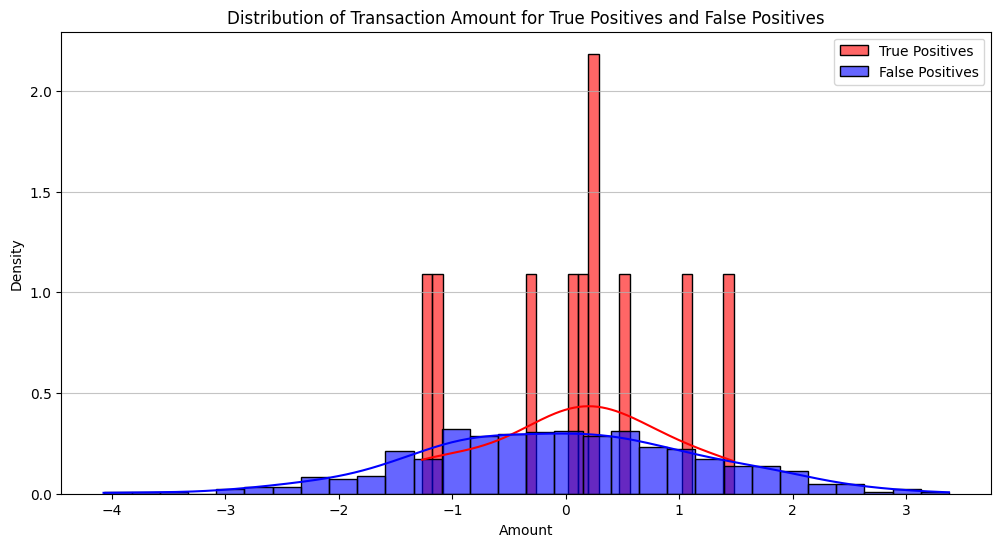

In [ ]:
# Define the missing DataFrames first
true_positive_indices = np.where((predictions == 1) & (y_test == 1))[0]
true_positives_df = X.iloc[true_positive_indices]

false_positive_indices = np.where((predictions == 1) & (y_test == 0))[0]
false_positives_df = X.iloc[false_positive_indices]

plt.figure(figsize=(12, 6))

# Plot histogram and KDE for True Positives
sns.histplot(true_positives_df['Amount'], color='red', label='True Positives', kde=True, stat='density', alpha=0.6, bins=30)

# Plot histogram and KDE for False Positives
sns.histplot(false_positives_df['Amount'], color='blue', label='False Positives', kde=True, stat='density', alpha=0.6, bins=30)

plt.title('Distribution of Transaction Amount for True Positives and False Positives')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print("Descriptive statistics for True Positives:")
display(true_positives_df.describe())

Descriptive statistics for True Positives:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.542289,0.077318,-0.644033,-0.054112,0.157058,0.416630,-0.120043,0.035144,0.420537,0.526904,...,-0.162206,-0.309226,-0.548770,0.302716,-0.204289,0.041706,-0.208043,-0.149803,0.108595,0.386366
std,1.201906,0.974956,1.596415,1.337009,1.029207,1.245605,1.229087,0.985643,1.511138,1.274438,...,1.502105,1.238182,1.112523,1.117772,1.366886,0.822297,1.277738,0.835952,0.851458,1.114731
min,-1.515051,-1.880418,-2.827528,-1.718621,-1.830970,-1.876995,-2.359025,-1.836562,-0.917858,-1.379480,...,-2.617525,-2.220471,-2.054457,-1.484372,-2.345015,-1.250567,-1.786568,-1.208730,-1.266540,-2.069947
25%,-0.300437,-0.492632,-1.902365,-0.993409,-0.382192,0.393702,-0.749668,-0.304735,-0.608540,-0.448591,...,-0.957663,-0.968875,-1.438378,-0.310610,-0.842578,-0.566086,-1.371004,-0.752349,-0.210569,0.143279
50%,0.480585,0.349341,-0.623725,-0.359448,0.385053,0.680891,0.040024,0.128875,-0.311811,0.440791,...,-0.061923,-0.312890,-0.370114,0.173212,-0.204502,0.234815,-0.117121,-0.285572,0.163655,0.482840
75%,1.558302,0.631258,0.393356,0.956048,0.605343,1.115416,0.390528,0.177108,1.509183,1.436733,...,0.438699,0.087952,0.017900,0.949841,0.882935,0.387523,0.769928,0.341268,0.434685,1.180356
max,2.038636,1.502942,1.835066,2.097945,1.517938,1.902836,2.097217,2.101781,3.026003,2.496499,...,2.604641,2.289778,1.517282,2.320280,1.593520,1.221619,1.556093,1.419047,1.479933,1.649742


In [ ]:
print("Descriptive statistics for False Positives:")
display(false_positives_df.describe())


Descriptive statistics for False Positives:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time
count,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,...,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,0.068839,-0.088982,-0.001899,-0.019478,-0.092425,0.062597,0.050705,0.043347,0.056311,-0.073410,...,0.026447,-0.071137,-0.063427,0.091714,-0.114101,-0.002267,0.134317,-0.073439,-0.040954,0.079795
std,1.313382,1.126586,1.089104,1.148644,1.295223,1.209056,1.226316,1.171065,1.149072,1.191752,...,1.168943,1.187985,1.115766,1.252888,1.310241,1.121560,1.211021,1.186166,1.233892,1.252664
min,-3.591070,-3.038806,-3.769623,-3.329234,-3.970571,-3.375723,-3.589528,-2.702720,-3.262729,-3.413184,...,-3.753578,-3.207099,-2.857037,-4.143812,-3.716382,-2.776830,-3.501578,-3.509713,-4.073134,-3.820155
25%,-0.828335,-0.900218,-0.707717,-0.824411,-0.952145,-0.853844,-0.753587,-0.828939,-0.788310,-0.888835,...,-0.776968,-0.790644,-0.915292,-0.748633,-1.045712,-0.780595,-0.707493,-0.936595,-0.895786,-0.845541
50%,0.090950,-0.043116,-0.010740,-0.063049,-0.050450,0.012922,0.034844,-0.003263,0.109283,-0.025496,...,-0.016026,-0.146780,-0.062539,0.110812,-0.067977,-0.008660,0.200862,-0.052158,-0.028729,0.140315
75%,0.981215,0.666675,0.697933,0.722177,0.817975,0.920500,0.925102,0.906082,0.845363,0.789453,...,0.832218,0.734212,0.701234,0.948434,0.773300,0.729882,0.941106,0.734773,0.809682,0.965356
max,4.161576,3.705193,4.748585,3.227146,3.742484,3.748232,4.261746,3.437946,3.435656,3.140365,...,3.476748,3.722479,3.487224,3.229531,3.440600,3.691088,3.599991,3.221406,3.376304,3.646971


In [ ]:
# Get indices for True Positives (correctly identified frauds)
true_positive_indices = np.where((predictions == 1) & (y_test == 1))[0]
true_positives_df = X.iloc[true_positive_indices]

print("True Positives (Actual Fraudulent Transactions Correctly Flagged):")
display(true_positives_df)

# Get indices for False Positives (normal transactions incorrectly flagged as fraud)
false_positive_indices = np.where((predictions == 1) & (y_test == 0))[0]
false_positives_df = X.iloc[false_positive_indices]

print("\nFalse Positives (Normal Transactions Incorrectly Flagged as Fraud):")
display(false_positives_df)

True Positives (Actual Fraudulent Transactions Correctly Flagged):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time
1024,1.681587,-0.368667,-2.034047,-0.385902,0.454199,1.902836,0.286000,-1.836562,-0.334736,1.989812,...,2.604641,2.289778,-0.839957,-1.484372,1.393905,-0.595714,0.077493,-0.177697,-1.085255,-0.680758
1651,-0.110271,0.226574,1.835066,-0.783453,0.534396,1.453433,-0.614686,0.618743,-0.035136,0.626899,...,-1.939322,-0.308775,-1.637852,-0.413399,-2.345015,0.207626,-1.636149,-0.860003,0.118313,-2.069947
3090,1.188447,0.681534,-1.507319,-1.718621,1.517938,0.640427,0.925869,0.179744,2.023956,1.460054,...,-0.096731,-2.220471,-0.342845,1.420171,-0.591283,0.415669,1.514086,-0.278549,0.489428,1.242752
6173,2.038636,1.502942,-0.485518,-1.695520,-0.839332,-1.677100,0.252475,2.101781,-0.765239,-0.397264,...,-0.252665,-1.498535,-2.054457,0.011504,-0.521927,-1.250567,0.151717,-0.292594,0.085790,0.149796
6579,-0.133293,-0.533953,0.533356,1.442886,0.628992,0.721355,-0.794662,0.104714,-0.449358,2.496499,...,1.169248,-0.092174,-0.362159,2.320280,0.112922,-0.477203,-0.311736,0.813026,1.094181,0.993168
6652,-0.390135,0.480429,-2.523497,2.097945,-0.267847,1.153089,-2.359025,-0.565849,-0.917858,0.254684,...,-0.027116,-0.733917,0.138149,-0.002245,1.083932,0.303085,-1.190043,-0.429386,0.208996,0.141106
7054,-1.515051,-1.880418,-0.761932,-1.063394,-0.420307,-1.876995,-1.246561,0.153036,-0.661600,-0.465700,...,-2.617525,-0.317005,-1.917590,-0.863541,1.593520,-0.842957,1.556093,-0.997401,-1.266540,0.476871
8402,1.947678,-0.743547,-2.827528,-0.332994,0.315908,1.002399,0.425371,0.169203,-0.288886,1.366773,...,0.217708,-1.047194,-0.378070,0.656073,-0.926343,1.221619,-1.431324,0.514256,-0.309356,1.649742
8630,-0.356152,0.936174,-0.026644,0.963130,-1.830970,0.363975,-0.172427,-0.250583,2.608224,-1.379480,...,0.512363,0.147994,1.517282,0.334920,0.279946,1.173503,0.975998,1.419047,1.479933,0.488809
9114,1.071441,0.472108,1.357734,0.934804,1.477603,0.482886,2.097217,-0.322786,3.026003,-0.683235,...,-1.192662,0.688042,0.389803,1.047764,-2.122548,0.262004,-1.786568,-1.208730,0.270456,1.472125



False Positives (Normal Transactions Incorrectly Flagged as Fraud):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time
5,1.595418,-1.162435,-0.210977,-0.591042,-0.343975,-1.166197,-0.690540,-1.672424,0.973694,-0.302109,...,-0.990432,0.529923,-0.358272,1.915212,-1.403973,-0.430872,-1.990492,0.078961,1.108368,1.453761
9,-0.116467,-0.664257,0.646640,0.744755,1.051384,1.055973,1.945541,2.117129,0.800763,0.106593,...,-1.575231,0.127706,0.915967,2.196333,-0.593810,-0.374270,-0.222443,-0.743372,-1.730364,-1.486234
37,-0.118142,-0.630979,-0.083247,-0.111010,0.809383,-0.986344,2.656520,-2.045208,-0.229145,-2.102195,...,-0.091353,-1.022215,0.084655,1.233401,-1.118379,-0.219042,0.844622,0.109068,1.996665,0.654585
41,3.217849,0.334621,0.205162,-0.979162,-2.566776,1.250460,2.404208,-0.304053,0.469237,0.518297,...,-0.420874,-1.394180,1.332262,-0.005526,-1.173699,2.342178,0.122078,-0.667874,1.347360,-0.929110
109,0.440503,0.864084,-1.453020,-1.093000,0.121284,0.568147,-0.826879,-1.382088,-0.890802,0.657337,...,-0.795275,0.420573,-0.702269,1.241994,0.039306,-0.333193,0.548788,-1.400558,0.016347,-0.119702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9845,0.663179,0.537478,1.183047,1.581667,0.040825,0.400714,2.342097,0.187156,-2.317324,0.253357,...,1.029060,0.647080,1.237004,0.612981,0.302587,-1.364923,-1.331344,1.062649,-0.618841,-1.520468
9878,0.020161,-1.312364,-0.801366,1.537134,-2.548366,-1.008191,-2.760054,2.118614,1.848796,0.859405,...,-1.131971,-0.375732,0.402451,1.007886,-0.090846,-0.253524,-0.931684,-0.335809,0.975940,1.210765
9944,3.242006,-0.526206,0.140578,-1.582491,1.381753,-0.416374,-0.094796,0.863788,1.237918,-1.567679,...,-0.135455,0.918798,-0.059151,3.222793,-1.814241,-0.463081,0.871499,-1.084333,-0.822015,1.077303
9961,-0.513499,-1.138054,-0.181510,0.703190,-0.521285,-1.690755,-1.058046,-1.362227,-0.127187,-2.058478,...,0.545675,-0.325525,-2.638440,-3.503993,0.439152,-0.961980,-0.978760,-0.811339,-0.905718,1.814595


In [ ]:
pip install torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.7 MB/s eta 0:00:00


In [ ]:
import torch
from torch_geometric.data import Data

# Example node features
x = torch.tensor([
    [0.2, 0.5],   # user1
    [0.1, 0.8],   # user2
    [0.9, 0.1],   # device
], dtype=torch.float)

# edges (connections)
edge_index = torch.tensor([
    [0, 1, 0],
    [2, 2, 1]
], dtype=torch.long)

y = torch.tensor([0, 1, 0])  # fraud labels

data = Data(x=x, edge_index=edge_index, y=y)

import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(2, 16)
        self.conv2 = GCNConv(16, 8)
        self.fc = torch.nn.Linear(8, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        return self.fc(x)

model = GNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    out = model(data)
    loss = F.cross_entropy(out, data.y)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    predictions_gnn = model(data)
    print("GNN Model Output (Logits):\n", predictions_gnn)
    print("Actual Labels:\n", data.y)

GNN Model Output (Logits):
 tensor([[ 0.1467, -0.4715],
        [ 0.1492, -0.5140],
        [ 0.2006, -0.6009]])
Actual Labels:
 tensor([0, 1, 0])
